In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Load Cleaned Dataset

df = pd.read_csv("cleaned_urban_water_dataset.csv")


X = df[[
    "Household_Size",
    "Seasonal_Index",
    "Garden_Area",
    "Income_Level",
    "Bathrooms",
    "Appliances_Count",
    "Rainfall",
    "Temperature",
    "Water_Price_Index"
]]

y = df["Daily_Liters_Used"]



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)



model = LinearRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)



mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape, "%")



joblib.dump(model, "advanced_water_model.pkl")

joblib.dump(scaler, "advanced_scaler.pkl")

print("Model and scaler saved successfully!")

Mean Absolute Error: 73.98044321397276
Mean Squared Error: 12209.493886365854
Root Mean Squared Error: 110.49657861837105
Mean Absolute Percentage Error: 15.809315477052277 %
Model and scaler saved successfully!


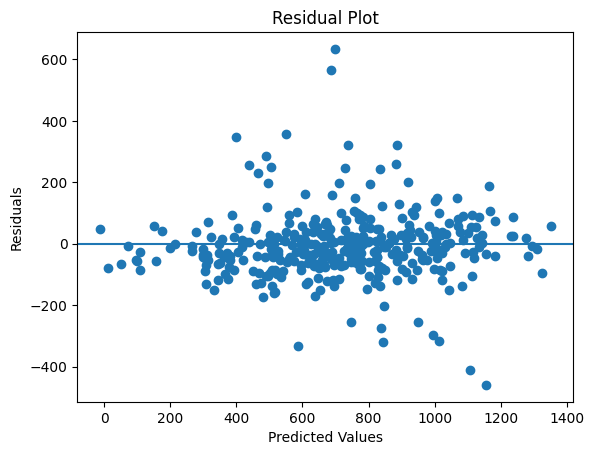

In [4]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

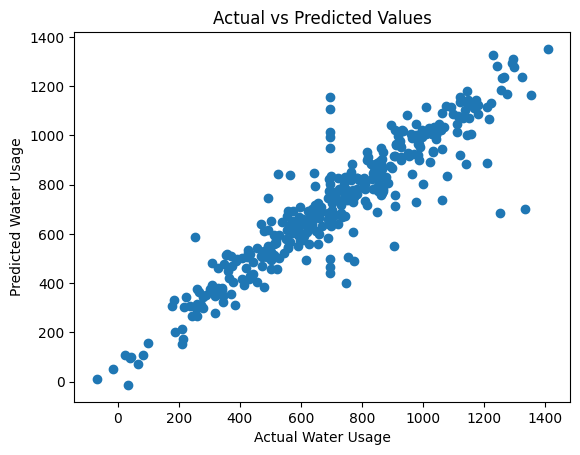

In [5]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Water Usage")
plt.ylabel("Predicted Water Usage")
plt.title("Actual vs Predicted Values")
plt.show()

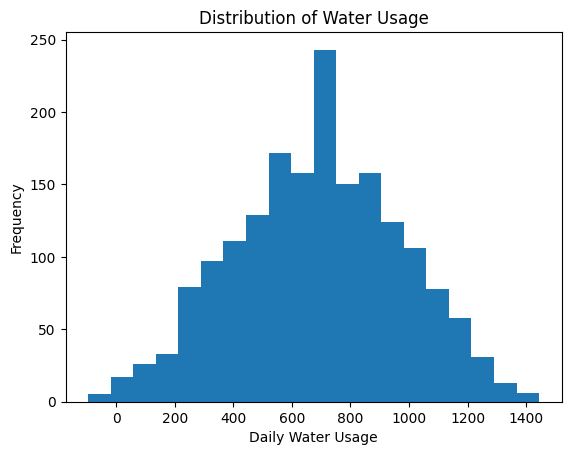

In [6]:
plt.hist(df["Daily_Liters_Used"], bins=20)
plt.xlabel("Daily Water Usage")
plt.ylabel("Frequency")
plt.title("Distribution of Water Usage")
plt.show()